# BANK MARKETING CAMPAIGN FUNNEL ANALYSIS

**Structure**
- Code and Charts
- Key Findings and Recommendations
- Further Analysis and Guidance in Running this project can be found in the README.md file.

## Imports and Loads

In [ ]:
# imports and loads
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
os.makedirs('../results', exist_ok=True)

df = pd.read_csv('../data/bank-full.csv', sep=';')
df.head(10)

# setups

# add a common column
df['contacted'] = 1
# rename column 'y' to 'converted'
df.rename(columns={'y':'converted'}, inplace=True)
# previously contacted
df['previous'] = df['previous'] > 0
# change converted into bool
df['converted'] = df['converted'] == 'yes'

# duration in minutes

df['duration_minutes'] = df['duration'] // 60

# create age groups 
bins = [18, 30, 45, 65, 80, 100]
labels = ['18-30', '31-45', '46-65', '66-80','81+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

# create balance groups
balance_bins = [-np.inf, 0, 500, 1000, 5000, np.inf]
balance_labels = ['Negative / 0', '0-500', '500-1000', '1000-5000', '5000+']
df['balance-group'] = pd.cut(df['balance'], bins=balance_bins, labels=balance_labels)


## Funnel Overview

Understanding the conversion journey:
1. **All Contacts:** Customers reached by bank
2. **Conversion:** Customers who subscribed to product

In [ ]:
# Funnel Mertrics
total_contacted = len(df)
total_converted = (df['converted'].sum())

conversion_rate = ((total_converted / total_contacted) * 100)

print("GENERAL INFORMATION")
print( f'Total Contacted: {total_contacted} people')
print( f'Total Converted: {total_converted} people')
print( f'Conversion Rate: {conversion_rate:.2f}%')

GENERAL INFORMATION
Total Contacted: 45211 people
Total Converted: 5289 people
Conversion Rate: 11.70%


## Contacted vs Converted Chart

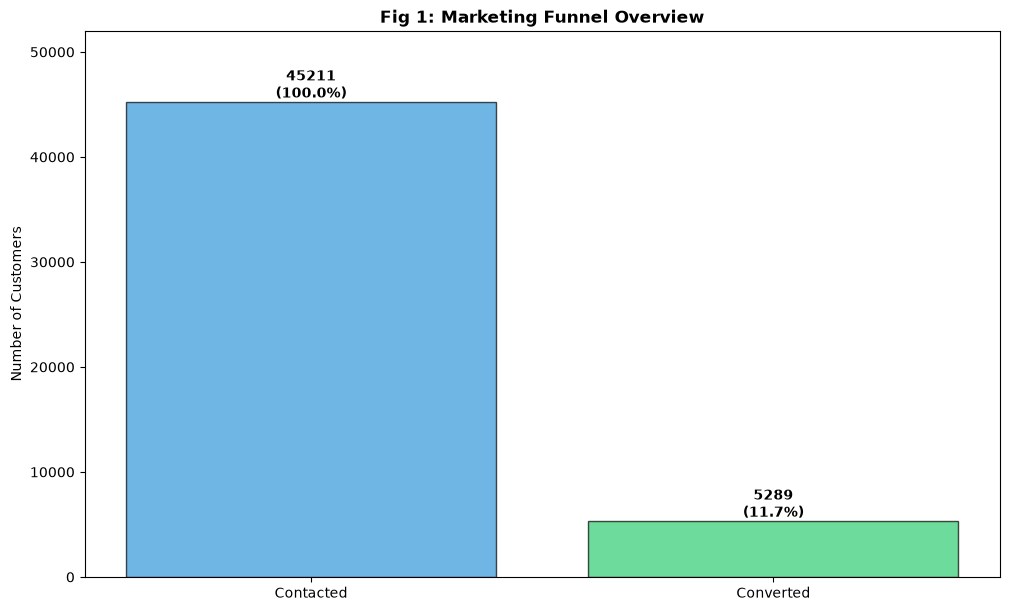

In [ ]:
plt.figure(figsize=(10,6))
stages = ['Contacted', 'Converted']
counts = [total_contacted, total_converted]
percentages = [100, conversion_rate]

colors = ['#3498db', '#2ecc71']
bars = plt.bar(stages, counts, color=colors, alpha=0.7, edgecolor='black')

for bar, count, pct in zip(bars, counts, percentages):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(count)}\n({pct:.1f}%)',
            ha='center', va='bottom', fontweight='bold')
plt.margins(y=0.15)
plt.tight_layout()
plt.title('Fig 1: Marketing Funnel Overview', fontsize=12, fontweight='bold')
plt.savefig('../results/01_funnel_overview.png', dpi=300)
plt.ylabel('Number of Customers')
plt.show()


## Conversion by Age Chart

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_67340\4286502252.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=conversion_by_age,  x='age_group', y='converted', palette='Set2')


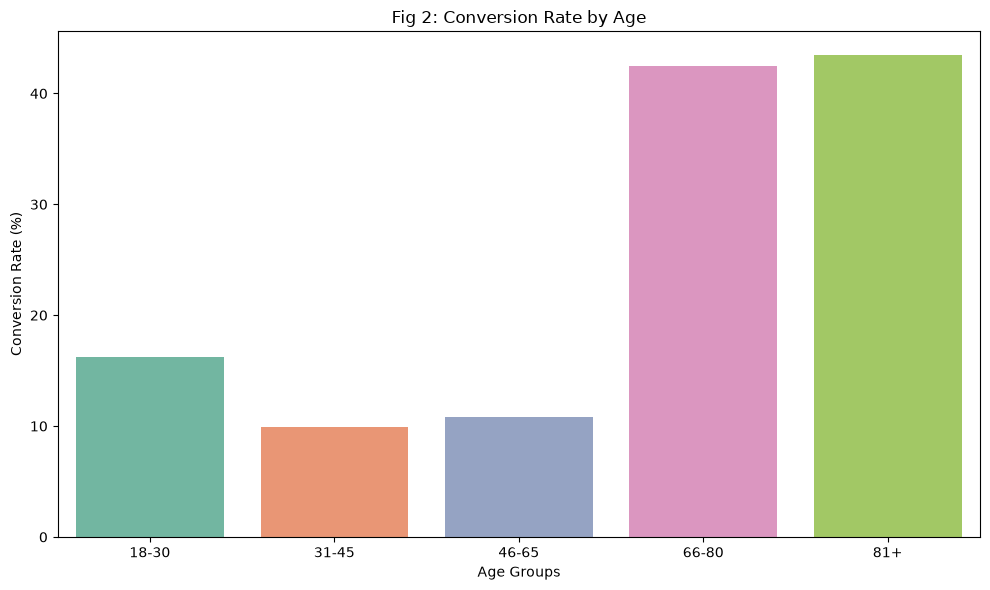

In [ ]:
# conversion by age 

conversion_by_age = ((df.groupby('age_group')['converted'].mean()) * 100).round(2).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=conversion_by_age,  x='age_group', y='converted', palette='Set2')
plt.title('Fig 2: Conversion Rate by Age')
plt.xlabel('Age Groups')
plt.ylabel('Conversion Rate (%)')
plt.tight_layout()
plt.savefig('../results/02_conversion_rate_by_age.png', dpi=300)
plt.show()

## Conversion by Job

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_67340\1822078038.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=conversion_by_jobs, x='converted', y='job', palette='Set1')


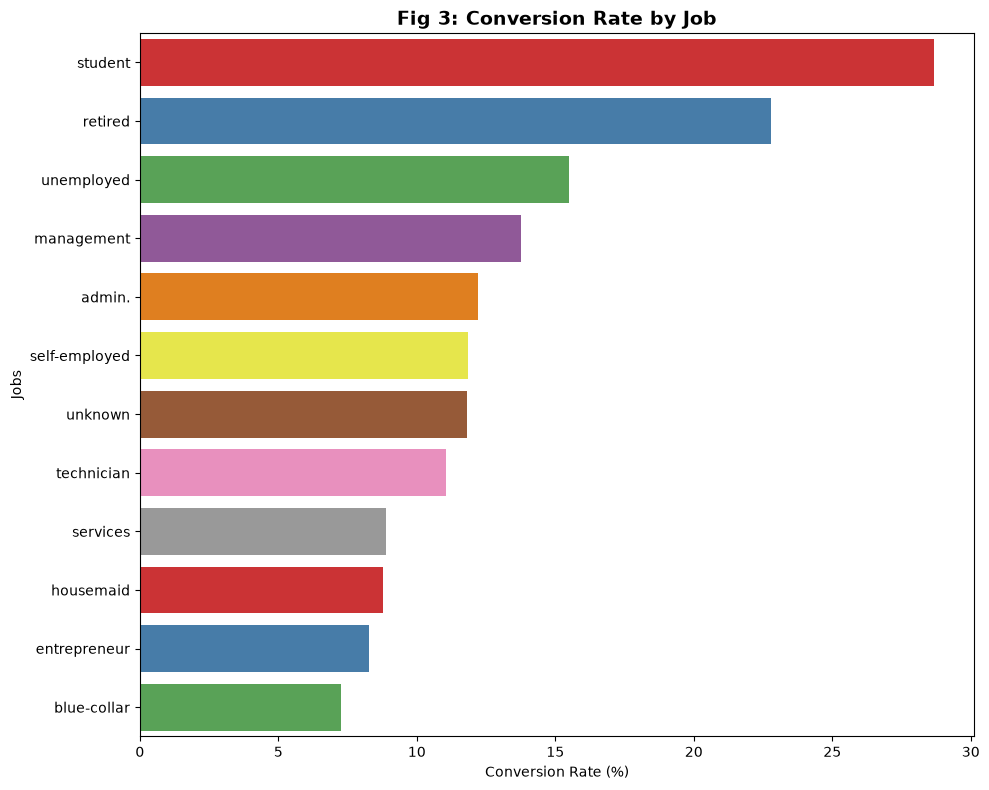

In [ ]:
# conversion by jobs

jobs = df['job'].value_counts().index
conversion_by_jobs = ((df.groupby('job')['converted'].mean()) * 100 ).round(2).sort_values(ascending=False).reset_index()
plt.figure(figsize=(10, 8))
sns.barplot(data=conversion_by_jobs, x='converted', y='job', palette='Set1')
plt.xlabel('Conversion Rate (%)')
plt.ylabel('Jobs')
plt.title('Fig 3: Conversion Rate by Job', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/03_conversion_rate_by_job.png', dpi=300)
plt.show()


## Impact of Previous Contact

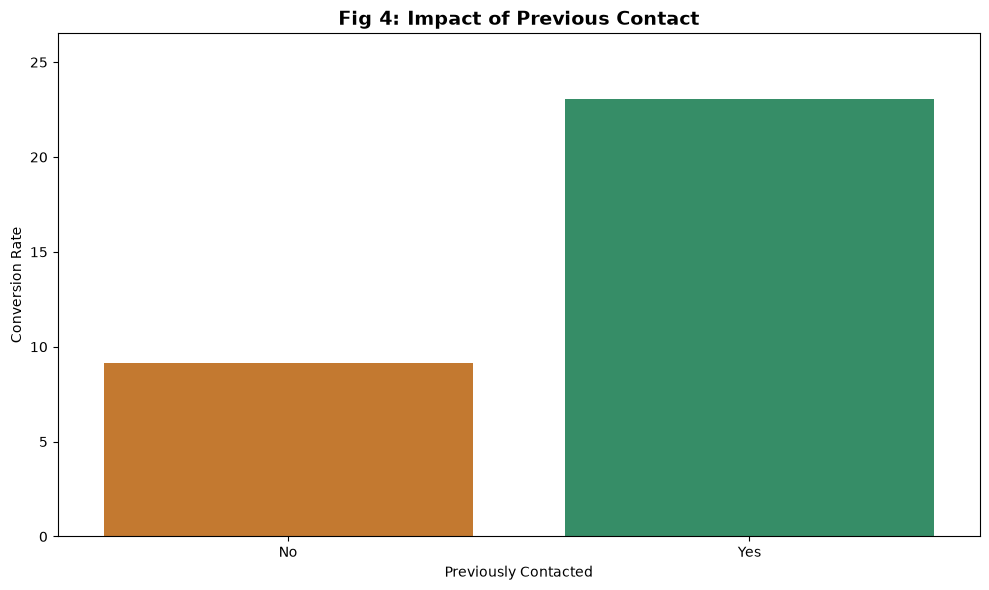

In [ ]:

plt.figure(figsize=(10, 6))
previously_contacted = (df.groupby('previous')['converted'].mean() * 100).reset_index()
sns.barplot(data=previously_contacted, x='previous', y='converted', palette=["#DB7918", "#289b69"], hue='previous', legend=False)
plt.xticks(ticks=[True, False], labels=['Yes', 'No'])
plt.xlabel('Previously Contacted')
plt.ylabel('Conversion Rate')
plt.title('Fig 4: Impact of Previous Contact', fontsize=14, fontweight='bold')
plt.margins(y=0.15)
plt.tight_layout()
plt.savefig('../results/04_conversion_by_previous_contact.png', dpi=300)
plt.show()

## Call Duration vs Conversion

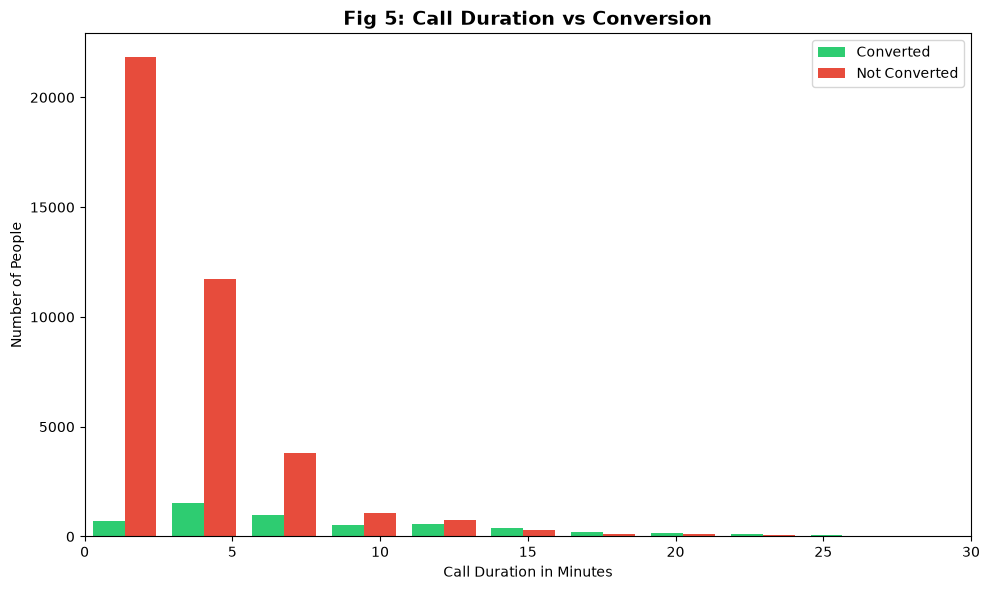

In [ ]:
# Duration (call length) vs conversion
converted = df[df['converted'] == True]['duration_minutes']
not_converted = df[df['converted'] == False ]['duration_minutes']

plt.figure(figsize=(10, 6))
plt.hist([converted, not_converted], bins= 30, label=['Converted', 'Not Converted'], color=['#2ecc71','#e74c3c'])
plt.legend(); 
plt.xlabel('Call Duration in Minutes')
plt.ylabel('Number of People')
plt.title('Fig 5: Call Duration vs Conversion', fontsize=14, fontweight='bold')
plt.xlim(0, 30)
plt.savefig('../results/05_conversion_by_call_duration.png', dpi=300)
plt.tight_layout()
plt.show()

## Conversion by Education Level

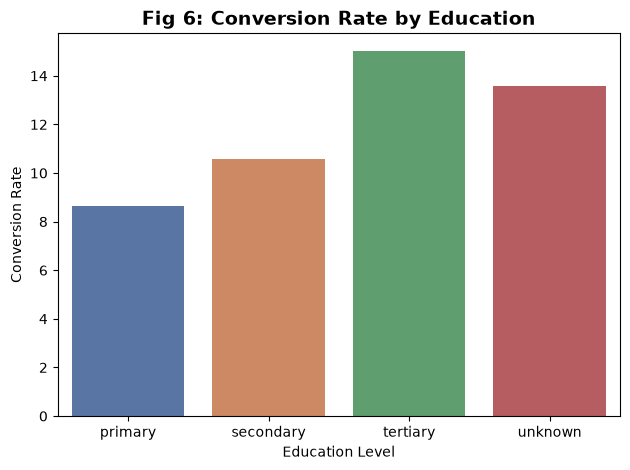

In [ ]:
# conversion by education
conversion_by_education = (df.groupby('education')['converted'].mean() * 100).reset_index()
plt.figure()
sns.barplot(data=conversion_by_education, x='education', y='converted', palette='deep', hue='education', legend=False)
plt.xlabel('Education Level')
plt.ylabel('Conversion Rate')
plt.title('Fig 6: Conversion Rate by Education', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/06_conversion_by_education.png', dpi=300)
plt.show(); 

## Conversion by Contact Method

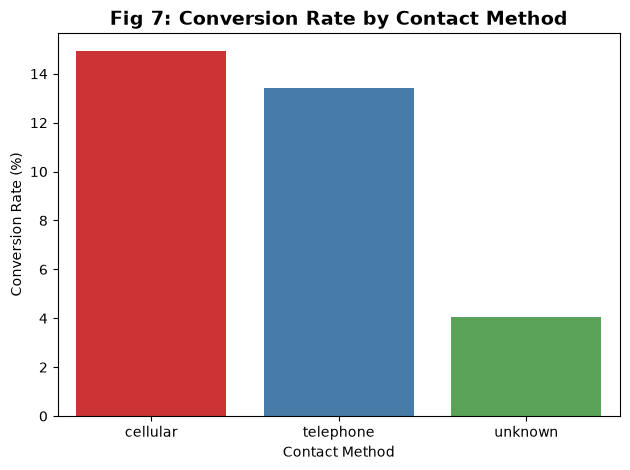

In [ ]:
# conversion by contact method

conversion_by_contact_method = (df.groupby('contact')['converted'].mean() * 100).reset_index()

plt.figure()
sns.barplot(data=conversion_by_contact_method, x='contact', y='converted', palette='Set1', hue='contact', legend=False)
plt.xlabel('Contact Method')
plt.ylabel('Conversion Rate (%)')
plt.title('Fig 7: Conversion Rate by Contact Method', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/07_conversion_rate_by_contact_method', dpi=300)
plt.show()

## Impact of the Previous Outcome

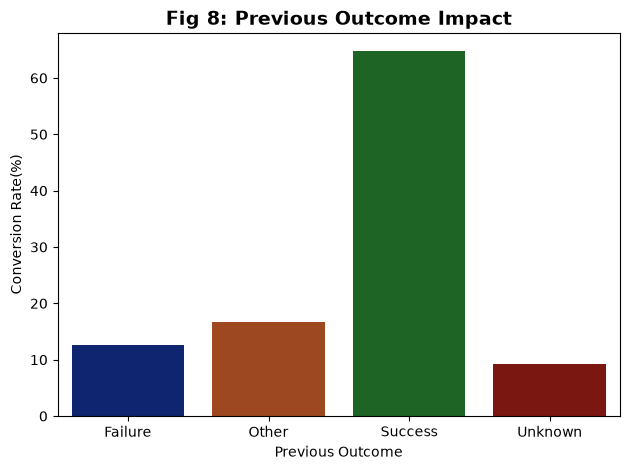

In [ ]:
#previous outcome impact

previous_outcome_influence_on_conversion_rate = (df.groupby('poutcome')['converted'].mean() * 100).reset_index()

plt.figure()
sns.barplot(data=previous_outcome_influence_on_conversion_rate, x='poutcome', y='converted', palette='dark', hue='poutcome', legend=False)
plt.xlabel('Previous Outcome')
plt.ylabel('Conversion Rate(%)')
plt.xticks(ticks=['failure', 'other', 'success', 'unknown'], labels=['Failure', 'Other', 'Success', 'Unknown'])
plt.title('Fig 8: Previous Outcome Impact', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/08_previous_outcome_impact.png', dpi=300)
plt.show(); 

## Hign Converting Demographic Combinations

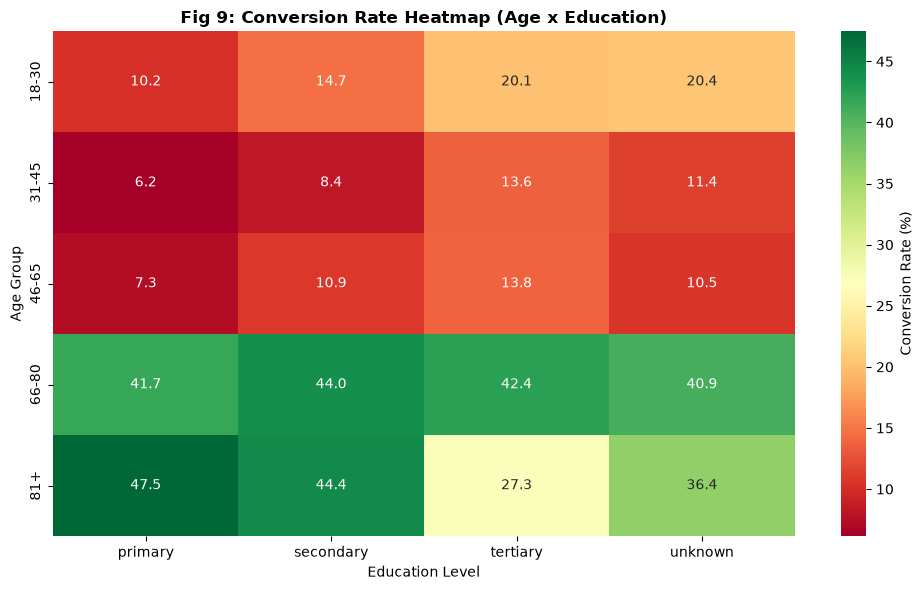

In [ ]:
# high converting demographic combination

conversion_pivot = df.pivot_table(
    values='converted',
    index='age_group',
    columns='education',
    aggfunc='mean'
) * 100

plt.figure(figsize=(10, 6))

sns.heatmap(conversion_pivot, annot=True, fmt='.1f', cmap='RdYlGn', cbar_kws={'label': 'Conversion Rate (%)'})
plt.title('Fig 9: Conversion Rate Heatmap (Age x Education)', fontsize=12, fontweight='bold')
plt.xlabel('Education Level')
plt.ylabel('Age Group')
plt.tight_layout()
plt.savefig('../results/09_conversion_heatmap_age_education.png', dpi=300)
plt.show()


In [ ]:
# Save key metrics to CSV
metrics_summary = pd.DataFrame({
    'Metric': ['Total Contacts', 'Total Conversions', 'Overall Conversion Rate (%)'],
    'Value': [total_contacted, total_converted, round(conversion_rate, 2)]
})

metrics_summary.to_csv('../results/conversion_metrics_summary.csv', index=False)


## Key Findings & Recommendations

### Top Conversion Insights:
1. **Age Group:** Seniors aged 66+ (43.7% – 46.0% conversion rate)
   - Hypothesis: They have more stable finances, more free time, and are more open to traditional banking products.

2. **Previous Contact:** Customers contacted in past campaigns (23% vs. 9% for first-timers)
   - Hypothesis: Re-engaging warm leads creates trust; people who listened once are much more likely to buy.

3. **Call Duration:** Long calls averaging 6+ minutes
   - Hypothesis: Longer conversations mean stronger customer engagement and a better understanding of the product.

4. **Education Level:** Tertiary/University graduates (15.1% conversion rate)
   - Hypothesis: Higher education level leads to stronger financial literacy and higher purchasing power.

5. **Contact Method:** Cellular/Mobile phones (15% conversion rate)
   - Hypothesis: People are more reachable, responsive, and comfortable answering personal mobile calls.

### High-Risk Segments (Low Conversion):
- **Young Professionals (Ages 31-45):** Convert at only ~9.6% because they are often too busy or do not see an immediate financial need.
- **Blue-Collar Workers:** Convert at only ~8% due to lower disposable income or lower alignment with standard banking products.

### Actionable Recommendations:
1. **Target High-Converting Demographics:** Focus heavily on seniors (66+) and individuals with tertiary education.
2. **Optimize Call Strategy:** Train sales agents to focus on call quality, aiming for a **5+ minute** minimum target instead of rushing volume.
3. **Leverage Previous Success:** Re-target customers who bought in the past, as they have a massive **64% conversion rate**.
4. **Channel Optimization:** Prioritize **Cellular** outreach and completely phase out "unknown" contact methods.
5. **Segment Strategy:** Design specific, simplified, or high-value offers tailored to busy young professionals to boost their low response rates.

### Estimated Impact:
- If we shift budget to **Seniors (66+)** and improve call lengths → we can unlock **~3,178 new conversions**.
- This targeting optimization alone can drive an estimated **+$1.59M in additional revenue** (assuming an average customer value of $500).